In [ ]:
'''Caracterización superficial de películas
delgadas dieléctricas por procesamiento de imágenes
'''

In [ ]:
'''
Debido a que esta investigación se encuentra en proceso de publicación, solamente adjunto esta versión de
código correspondiente a los procesamientos de Canny y de Hough como lo que se practicó en clase

El resto de procesamiento de python se omite ya que forma parte de una investigación más extensa
'''

In [ ]:
# Procesamiento de imágenes
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detectar_circulos(ruta, minR, maxR, param2):
    img = cv2.imread(ruta, 0)

    # Eliminar la barra de información inferior
    img = img[:-90, :]

    # Mejorar contraste
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

    # Suavizado
    blur = cv2.GaussianBlur(img, (5,5), 1)

    # Canny
    edges = cv2.Canny(blur, 50, 150)

    # Hough
    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=25,
        param1=100,
        param2=param2,
        minRadius=minR,
        maxRadius=maxR
    )

    return img, edges, circles

In [ ]:
# Archivos a utilizar
img100, edges100, c100 = detectar_circulos(
    "AZO-10nm-100_000x_02.png", 10, 35, 25
)

img50, edges50, c50 = detectar_circulos(
    "AZO-10nm-50_000x_01.png", 5, 20, 25
)

c100 = np.round(c100[0]).astype(int)
c50 = np.round(c50[0]).astype(int)

print("Círculos detectados:")
print("100,000x:", len(c100))
print("50,000x :", len(c50))

Círculos detectados:
100,000x: 130
50,000x : 520


In [ ]:
# Carga de la detección de círculos

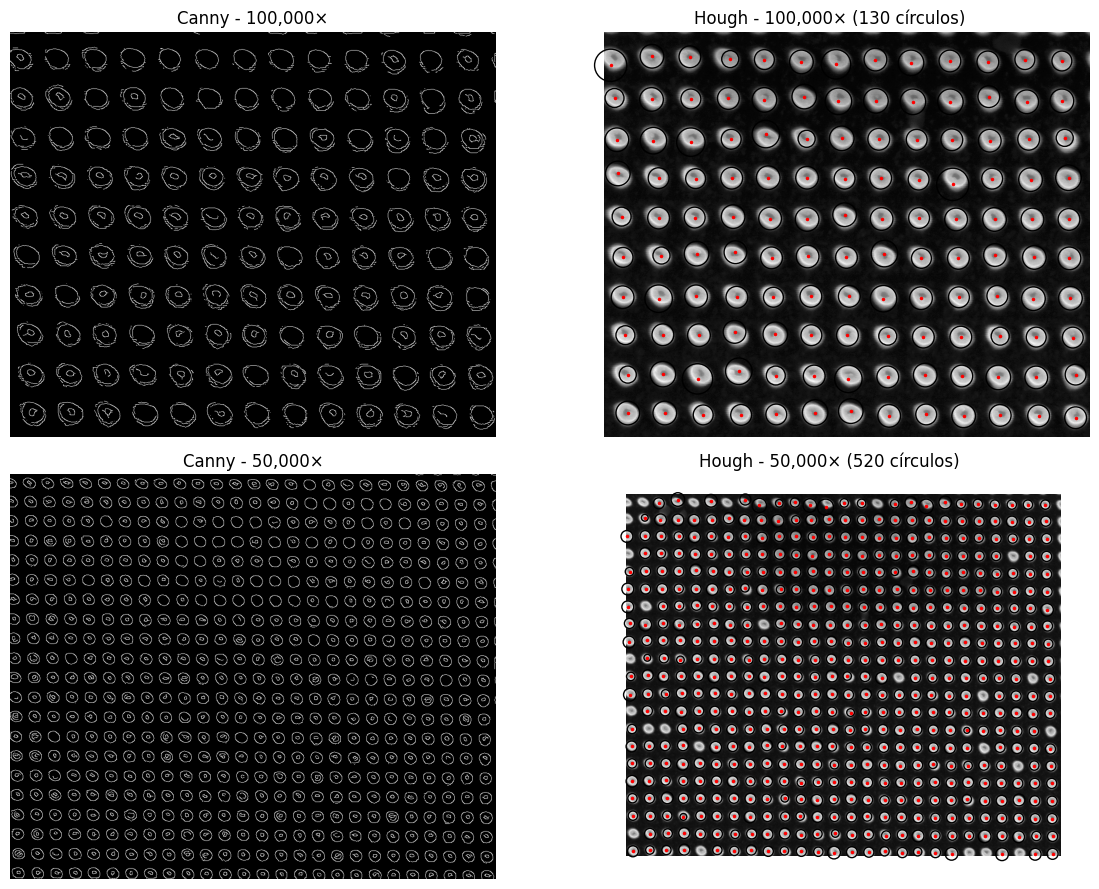

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12,9))

# 100,000x - Canny
ax[0,0].imshow(edges100, cmap="gray")
ax[0,0].set_title("Canny - 100,000×")
ax[0,0].axis("off")

# 100,000x - Hough
ax[0,1].imshow(img100, cmap="gray")
for x, y, r in c100:
    ax[0,1].add_patch(plt.Circle((x,y), r, fill=False, linewidth=1))
    ax[0,1].plot(x, y, "r.", markersize=3)

ax[0,1].set_title(f"Hough - 100,000× ({len(c100)} círculos)")
ax[0,1].axis("off")

# 50,000x - Canny
ax[1,0].imshow(edges50, cmap="gray")
ax[1,0].set_title("Canny - 50,000×")
ax[1,0].axis("off")

# 50,000x - Hough
ax[1,1].imshow(img50, cmap="gray")
for x, y, r in c50:
    ax[1,1].add_patch(plt.Circle((x,y), r, fill=False, linewidth=1))
    ax[1,1].plot(x, y, "r.", markersize=3)

ax[1,1].set_title(f"Hough - 50,000× ({len(c50)} círculos)")
ax[1,1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
diam100 = 2 * np.mean(c100[:,2])
diam50 = 2 * np.mean(c50[:,2])

print(f"Radio promedio 100,000x: {np.mean(c100[:,2]):.2f} px")
print(f"Radio promedio 50,000x : {np.mean(c50[:,2]):.2f} px")

print(f"Diámetro promedio 100,000x: {diam100:.2f} px")
print(f"Diámetro promedio 50,000x : {diam50:.2f} px")

Radio promedio 100,000x: 23.88 px
Radio promedio 50,000x : 11.99 px
Diámetro promedio 100,000x: 47.75 px
Diámetro promedio 50,000x : 23.98 px


In [ ]:
escala100 = 1000 / 337   # nm/pixel
escala50  = 2000 / 337   # nm/pixel

tam100 = diam100 * escala100
tam50 = diam50 * escala50

print(f"Diámetro estimado 100,000x: {tam100:.1f} nm")
print(f"Diámetro estimado 50,000x : {tam50:.1f} nm")

Diámetro estimado 100,000x: 141.7 nm
Diámetro estimado 50,000x : 142.3 nm


In [ ]:
area100 = (1024/337) * (880/337)
area50  = (1024/337*2) * (880/337*2)

dens100 = len(c100) / area100
dens50 = len(c50) / area50

print(f"Densidad 100,000x: {dens100:.2f} círculos/µm²")
print(f"Densidad 50,000x : {dens50:.2f} círculos/µm²")

Densidad 100,000x: 16.38 círculos/µm²
Densidad 50,000x : 16.38 círculos/µm²
